<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_OPSD_TimeSeries_Energy_DE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Open Power System Data (OPSD) — 전력·에너지 시계열(가입/키 없이)
### 예제: 독일(DE) 전력 수요(load) · 태양광(solar) · 풍력(wind) · 가격(price)


> **학습목표 (전체(이 노트북))**
>
- OPSD(Time series) 공개 CSV를 **가입/키 없이** 다운로드하여 전력 시계열을 구성한다.
- 전력 수요·재생에너지·가격 시계열의 주기성(일주기/주간)과 이상치/결측을 진단한다.
- STL/ACF/정상성 점검 후, 24시간 주기의 Seasonal Naïve 베이스라인 예측을 수행한다.


### 🧭 수업 운영 포인트(‘현업형 데이터’)
- 전력 데이터는 **강한 일주기(24시간) + 주간(7일) 패턴**이 있어서, STL/ACF 설명에 매우 적합합니다.
- ‘수요(load)’와 ‘재생발전(풍력/태양광)’의 관계를 보면서 **외생변수(X)** 개념으로 확장하기도 쉽습니다.


## 0) 데이터 설명: Open Power System Data (OPSD) — Time series
**무엇을 주나?**
- 유럽 여러 국가/지역의 전력 시스템 관련 시계열(수요, 풍력·태양광 발전/설비, 가격 등)을 제공합니다.
- 여러 해상도(15/30/60분)와 파일 포맷(singleindex/multiindex/stacked)을 제공합니다.

**가입/키 필요?**
- **필요 없습니다.** (공개 다운로드)

**다운로드 방식(본 노트북)**
- 아래 공개 URL에서 CSV를 직접 읽습니다.
  - landing page: https://data.open-power-system-data.org/time_series/
  - csv: https://data.open-power-system-data.org/time_series/time_series_60min_singleindex.csv
  - (대안) zip: https://data.open-power-system-data.org/time_series/opsd-time_series-2020-10-06.zip

**주의(수업 안정성 팁)**
- 원본 CSV는 용량이 큽니다(100MB+). 실습에서는
  1) **필요한 컬럼만 선택(usecols)**,
  2) 한 번 다운로드 후 **로컬 캐시**,
  3) 기간을 잘라서(예: 최근 2~3년) 사용하는 것이 안정적입니다.


## 1) 라이브러리/환경


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (12, 4)


## 2) 데이터 불러오기(큰 파일 안전하게)
### 전략
1) 먼저 헤더만 읽어서 컬럼명을 확인
2) 필요한 컬럼만 `usecols`로 선택해서 로드
3) 로컬 CSV로 저장해 재실행 시 재다운로드를 피함


> **학습목표 (2) 로딩)**
>
- 대용량 CSV를 ‘필요 컬럼만’ 로드하는 습관을 갖는다.
- 시간 인덱스(utc/cet) 중 무엇을 쓸지 선택한다.
- 로컬 캐시로 수업 중 네트워크 변수를 줄인다.


In [7]:
CSV_URL = 'https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv'
CACHE_FILE = 'opsd_time_series_60min_singleindex.csv'

# (1) 헤더만 확인(로컬 캐시가 있으면 로컬에서)
header_src = CACHE_FILE if os.path.exists(CACHE_FILE) else CSV_URL
cols = pd.read_csv(header_src, nrows=0).columns.tolist()
print('n_columns:', len(cols))
print('first 20 columns:', cols[:20])

# (2) 본 실습에서 사용할 컬럼 선택(독일 DE 예시)
# - timestamp는 보통 'utc_timestamp'와 'cet_cest_timestamp'가 함께 있음
# - 변수명은 예: DE_load_actual_entsoe_transparency, DE_solar_generation_actual 등
usecols = [
    c for c in cols
    if c in [
        'utc_timestamp',
        'cet_cest_timestamp',
        'DE_load_actual_entsoe_transparency',
        'DE_solar_generation_actual',
        'DE_wind_generation_actual',
        'DE_price_day_ahead'
    ]
]
print('usecols:', usecols)

# (3) 데이터 로드(로컬 캐시가 없으면 URL에서)
src = CACHE_FILE if os.path.exists(CACHE_FILE) else CSV_URL
df = pd.read_csv(src, usecols=usecols)

# 로컬 캐시 저장(처음만)
if not os.path.exists(CACHE_FILE):
    # 전체 파일을 캐시하고 싶으면 별도 다운로드 권장.
    # 여기서는 usecols만 읽었으므로, 같은 src를 다시 쓰지 않도록 'subset 캐시' 저장.
    subset_cache = 'opsd_DE_subset_60min.csv'
    df.to_csv(subset_cache, index=False)
    print('Saved subset cache:', subset_cache)

display(df.head())
print(df.shape)

n_columns: 300
first 20 columns: ['utc_timestamp', 'cet_cest_timestamp', 'AT_load_actual_entsoe_transparency', 'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead', 'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual', 'BE_wind_onshore_generation_actual', 'BG_load_actual_entsoe_transparency', 'BG_load_forecast_entsoe_transparency', 'BG_solar_generation_actual', 'BG_wind_onshore_generation_actual', 'CH_load_actual_entsoe_transparency', 'CH_load_forecast_entsoe_transparency', 'CH_solar_capacity']
usecols: ['utc_timestamp', 'cet_cest_timestamp', 'DE_load_actual_entsoe_transparency', 'DE_solar_generation_actual', 'DE_wind_generation_actual']
Saved subset cache: opsd_DE_subset_60min.csv


,utc_timestamp,cet_cest_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,41151.0,NaN,8852.0
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,40135.0,NaN,9054.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,39106.0,NaN,9070.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,38765.0,NaN,9163.0


(50401, 5)


### 🔎 출력 해석 포인트 (로딩 해석)
- 원본 파일은 매우 크므로, `usecols`로 필요한 변수만 가져오면 실습이 안정적입니다.
- 시간 컬럼은 UTC와 CET/CEST(유럽 현지) 두 가지가 함께 제공될 수 있습니다.
- 수업에서는 ‘하루 주기(24h)’를 보기 위해 현지시간(cet_cest) 기준이 직관적일 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 대용량 CSV를 실습에서 안정적으로 다루려면 필요한 컬럼만 (_____)로 읽는다.
- Q2. OPSD는 시간 컬럼으로 UTC와 (_____) 타임스탬프를 함께 제공할 수 있다.
- Q3. 일주기(24시간) 패턴을 보기에는 현지시간 기준이 더 (_____)적일 수 있다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. usecols
- A2. CET/CEST
- A3. 직관

</details>


## 3) 시간 인덱스 설정 + 기본 전처리
- 여기서는 `cet_cest_timestamp`(중앙유럽 현지 시간) 기준으로 인덱스를 잡습니다.
- 결측치는 그대로 두고, 필요한 경우 보간/대체를 선택합니다.


In [8]:
# 시간 인덱스 설정
ts_col = 'cet_cest_timestamp' if 'cet_cest_timestamp' in df.columns else 'utc_timestamp'
df[ts_col] = pd.to_datetime(df[ts_col], utc=True)
df = df.set_index(ts_col).sort_index()

# 컬럼 이름 단순화
rename_map = {
    'DE_load_actual_entsoe_transparency': 'load_MW',
    'DE_solar_generation_actual': 'solar_MW',
    'DE_wind_generation_actual': 'wind_MW',
    'DE_price_day_ahead': 'price_EUR'
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})

display(df.head())
print(df.isna().sum())

,utc_timestamp,load_MW,solar_MW,wind_MW
cet_cest_timestamp,,,,
2014-12-31 23:00:00+00:00,2014-12-31T23:00:00Z,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,2015-01-01T00:00:00Z,41151.0,NaN,8852.0
2015-01-01 01:00:00+00:00,2015-01-01T01:00:00Z,40135.0,NaN,9054.0
2015-01-01 02:00:00+00:00,2015-01-01T02:00:00Z,39106.0,NaN,9070.0
2015-01-01 03:00:00+00:00,2015-01-01T03:00:00Z,38765.0,NaN,9163.0


utc_timestamp      0
load_MW            1
solar_MW         104
wind_MW           75
dtype: int64


### 🔎 출력 해석 포인트 (전처리 해석)
- 전력 데이터는 결측이 발생할 수 있습니다(국가/변수/기간별).
수요·발전은 MW 단위(순간/평균 전력)로 제공되는 경우가 많습니다.
가격은 단위가 EUR/MWh 형태로 제공되는 경우가 많으니, 메타데이터를 함께 확인하는 습관이 좋습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 결측치가 있을 때 가장 먼저 할 일은 결측의 (_____)과 (_____)을 확인하는 것이다.
- Q2. MW는 전력 단위로, 시간당 에너지(MWh)와는 (_____) 개념이다.
- Q3. 가격 컬럼은 보통 단위가 (_____) 형태일 수 있다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 규모
- A2. 패턴(연속/산발)
- A3. 다른
- A4. EUR/MWh

</details>


## 4) 시각화: 수요/재생발전/가격
일주기(24h) 패턴과 주간 패턴, 그리고 재생발전의 변동성을 관찰합니다.


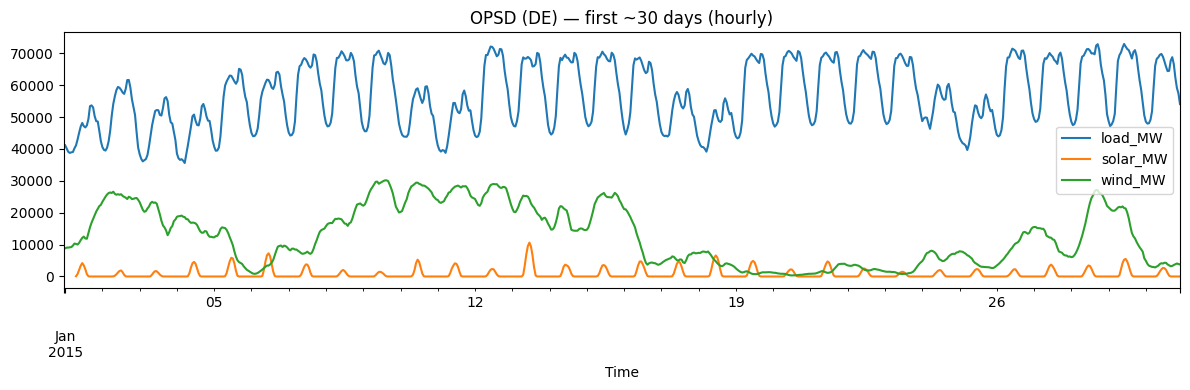

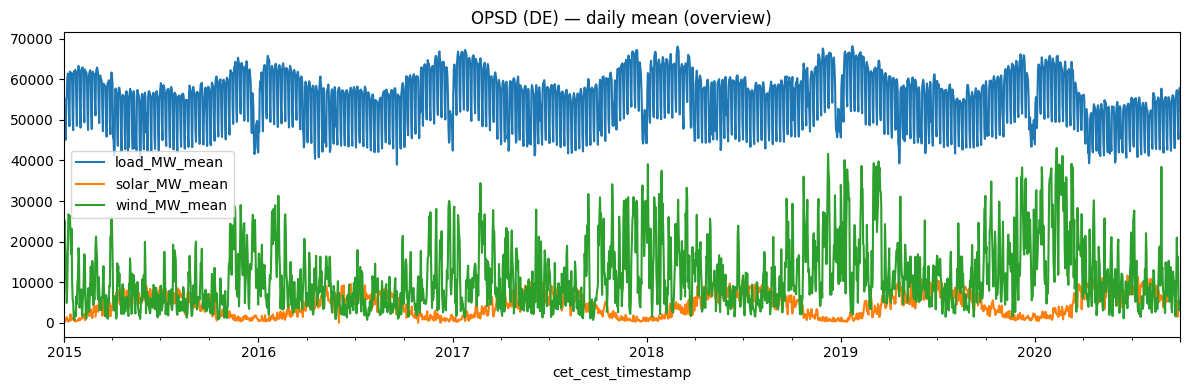

In [9]:
cols_to_plot = [c for c in ['load_MW','solar_MW','wind_MW','price_EUR'] if c in df.columns]
df[cols_to_plot].iloc[:24*30].plot(title='OPSD (DE) — first ~30 days (hourly)')
plt.xlabel('Time'); plt.tight_layout(); plt.show()

# 전체 기간에서 보기(다운샘플): 일별 평균/합계로 바꾸면 한눈에 보기 쉬움
daily = pd.DataFrame(index=df.select_dtypes(include=np.number).resample('D').mean().index)
if 'load_MW' in df.columns:
    daily['load_MW_mean'] = df['load_MW'].resample('D').mean()
if 'solar_MW' in df.columns:
    daily['solar_MW_mean'] = df['solar_MW'].resample('D').mean()
if 'wind_MW' in df.columns:
    daily['wind_MW_mean'] = df['wind_MW'].resample('D').mean()
if 'price_EUR' in df.columns:
    daily['price_EUR_mean'] = df['price_EUR'].resample('D').mean()

daily.plot(title='OPSD (DE) — daily mean (overview)')
plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (시각화 해석)
- 시간별 데이터는 일주기 패턴이 뚜렷하지만, 전체 기간을 한 번에 보면 그래프가 과밀해질 수 있습니다.
- 일별 평균으로 요약하면 장기 추세·계절을 보기 쉬워집니다.
- 재생발전(풍력/태양광)은 기상 의존성이 강해 변동성이 큽니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 시간별 데이터를 전체 기간으로 그리면 그래프가 (_____)해질 수 있다.
- Q2. 일별 평균은 장기 (_____)와 계절을 보기 쉽게 한다.
- Q3. 재생발전 변동성의 큰 원인은 (_____) 요인이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 과밀
- A2. 추세(trend)
- A3. 기상(날씨)

</details>


## 5) STL/ACF 진단(시간별)
여기서는 ‘수요(load)’의 시간별 패턴을 중심으로 진단합니다.
- 시간별 데이터의 대표 주기: **24(일주기)**
- 데이터에 따라 **168(=24×7, 주간)**도 의미가 있을 수 있습니다.


> **학습목표 (5) 진단)**
>
- STL로 Trend/Seasonal/Residual을 분해한다.
- ACF/PACF로 24시간 주기의 자기상관을 확인한다.


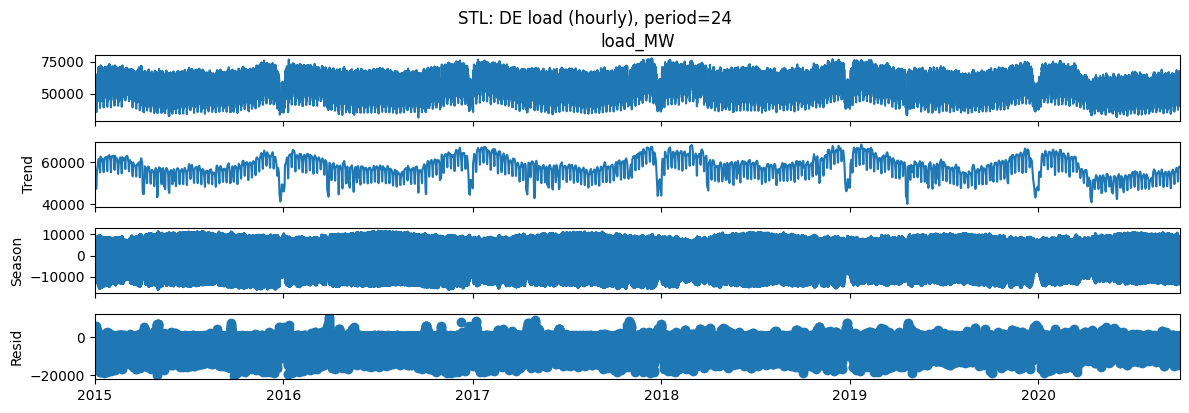

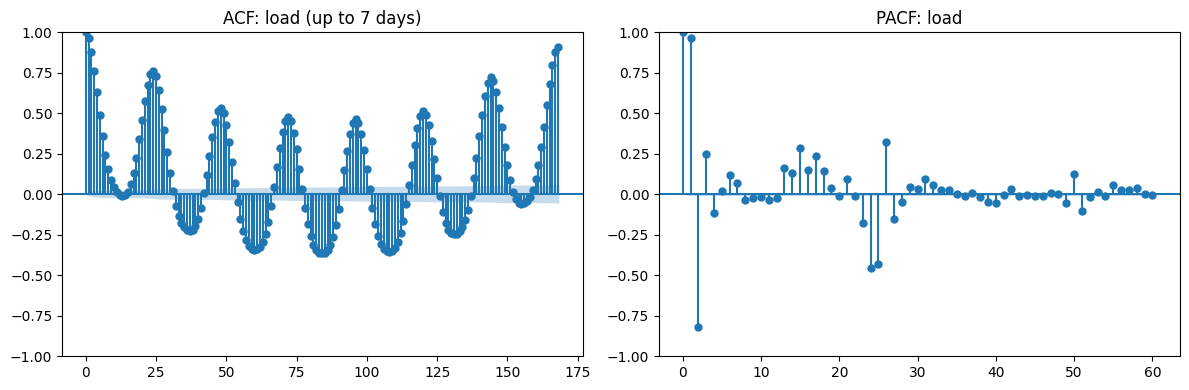

In [10]:
y = df['load_MW'].dropna() if 'load_MW' in df.columns else None
assert y is not None, 'load_MW column not found. Check selected columns.'

# STL (period=24): 시간별 데이터의 일주기
stl = STL(y, period=24, robust=True)
res = stl.fit()
res.plot(); plt.suptitle('STL: DE load (hourly), period=24', y=1.02); plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, lags=24*7, ax=ax[0]); ax[0].set_title('ACF: load (up to 7 days)')
plot_pacf(y, lags=60, ax=ax[1], method='ywm'); ax[1].set_title('PACF: load')
plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (진단 해석)
- ACF에서 24, 48, 72… 래그에 반복 피크가 있으면 일주기 패턴이 강하다는 뜻입니다.
- STL의 Seasonal 성분은 평균적인 하루 패턴을 추출하는 역할을 합니다.
- Residual의 큰 스파이크는 휴일/이벤트/이상치 또는 데이터 품질 이슈일 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 시간별 데이터에서 일주기 패턴은 ACF의 래그 (_____) 배수에서 피크로 나타날 수 있다.
- Q2. STL의 Seasonal 성분은 반복 (_____) 패턴을 나타낸다.
- Q3. Residual의 스파이크는 휴일/이벤트 또는 (_____) 가능성을 시사한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 24
- A2. 계절(주기)
- A3. 이상치(outlier)

</details>


## 6) 베이스라인 예측: Seasonal Naïve(24시간)
전력 수요는 ‘어제 같은 시간’이 매우 강력한 기준선이 됩니다.
- Seasonal Naïve(h=24):  ŷ_t = y_{t-24}


> **학습목표 (6) 예측)**
>
- 24시간 Seasonal Naïve 예측을 만든다.
- MAE/RMSE로 기준선 성능을 계산한다.


Seasonal Naive(h=24) | RMSE=5,910.74, MAE=3,795.76  (MW)


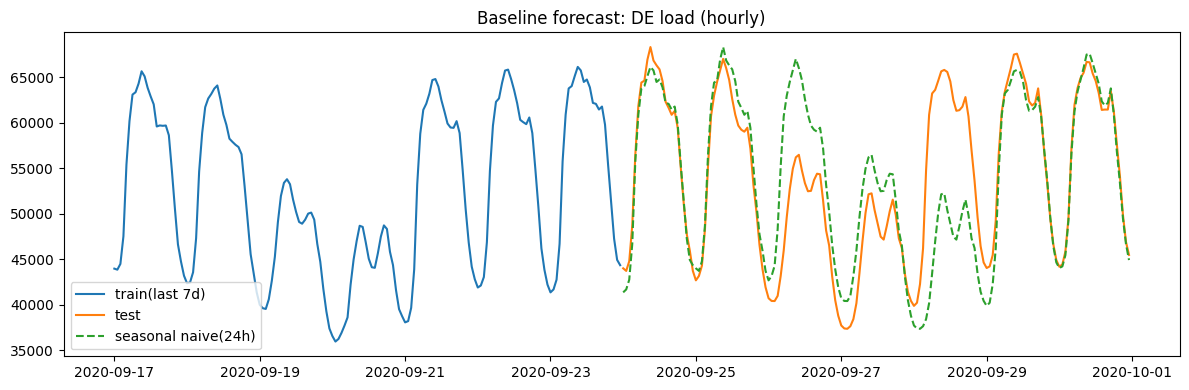

In [11]:
h = 24
y2 = y.copy()

# train/test split: 마지막 7일(=168시간) 테스트
test_n = 24*7
y_train = y2.iloc[:-test_n]
y_test  = y2.iloc[-test_n:]

y_pred = pd.Series(index=y_test.index, dtype=float)
for t in y_test.index:
    t_lag = t - pd.Timedelta(hours=h)
    if t_lag in y2.index:
        y_pred.loc[t] = y2.loc[t_lag]

rmse = math.sqrt(mean_squared_error(y_test.dropna(), y_pred.dropna()))
mae  = mean_absolute_error(y_test.dropna(), y_pred.dropna())
print(f'Seasonal Naive(h={h}) | RMSE={rmse:,.2f}, MAE={mae:,.2f}  (MW)')

plt.figure(figsize=(12,4))
plt.plot(y_train.index[-24*7:], y_train.iloc[-24*7:], label='train(last 7d)')
plt.plot(y_test.index, y_test, label='test')
plt.plot(y_pred.index, y_pred, label='seasonal naive(24h)', linestyle='--')
plt.title('Baseline forecast: DE load (hourly)')
plt.legend(); plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (예측 해석)
- 전력 수요는 ‘어제 같은 시간’이 강력한 기준선이므로, 복잡한 모델은 이 기준선을 ‘확실히’ 이겨야 의미가 있습니다.
- 휴일/특이 이벤트가 있으면 seasonal naive가 크게 빗나갈 수 있습니다(Residual 스파이크와 연결).
- 다음 단계로는 wind/solar/price를 외생변수로 넣는 회귀/ARIMAX로 확장하기 좋습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Seasonal Naïve(h=24)는 ŷ_t = y_{t-(_____) } 형태다.
- Q2. 전력 수요에서 흔히 강한 기준선은 ‘어제 같은 (_____)’이다.
- Q3. 외생변수를 추가한 모델을 ARIMAX라고 할 때 외생변수는 보통 (_____)로 표기한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 24시간
- A2. 시간
- A3. X

</details>


## ✅ 마무리 (요약 3줄)
1) OPSD time series는 **가입/키 없이** 공개 다운로드로 전력 수요·재생발전·가격 시계열을 실습할 수 있습니다.
2) 전력 데이터는 **24시간/7일 주기**가 뚜렷해 STL/ACF 진단에 매우 적합합니다.
3) 예측은 Seasonal Naïve(24h) 같은 강력한 기준선부터 비교하고, 이후 외생변수(풍력/태양광/가격)로 확장하는 것이 정석입니다.

### ➡️ 다음 노트북 연결
- (A) wind/solar를 X로 넣어 load를 설명하는 회귀/ARIMAX
- (B) 휴일 더미를 추가해 오차를 줄이는 이벤트 모델
- (C) 멀티국가 비교(예: DE vs FR vs GB)로 패턴 비교
